/home/ubuntu/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


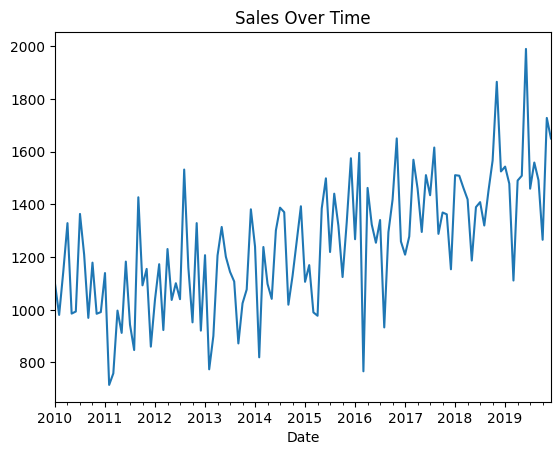

Forecasted Sales: 2020-01-31    1556.401603
2020-02-29    1550.371594
2020-03-31    1458.481452
2020-04-30    1568.143710
2020-05-31    1599.200875
2020-06-30    1567.998063
2020-07-31    1559.176320
2020-08-31    1526.873090
2020-09-30    1546.506439
2020-10-31    1568.055240
2020-11-30    1563.908698
2020-12-31    1559.596609
Freq: ME, Name: predicted_mean, dtype: float64


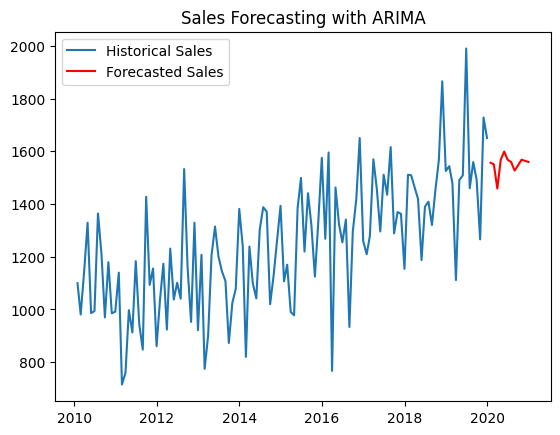

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Load sales data with proper date parsing and frequency
data = pd.read_csv('sales_time_series.csv', parse_dates=['Date'], index_col='Date')

# Ensure the data has a frequency, and explicitly set it if it's not inferred
data.index = pd.to_datetime(data.index)  # Ensure it's datetime
data = data.asfreq('ME')  # Set frequency to month-end

# Plotting the time series
data['Sales'].plot()
plt.title('Sales Over Time')
plt.show()

# Fit ARIMA model
model = ARIMA(data['Sales'], order=(5, 1, 0))  # Example ARIMA parameters
model_fit = model.fit()

# Forecast the next 12 months
forecast = model_fit.forecast(steps=12)
print(f"Forecasted Sales: {forecast}")

# Plot the forecast
plt.plot(data.index, data['Sales'], label='Historical Sales')
plt.plot(pd.date_range(start=data.index[-1], periods=13, freq='ME')[1:], forecast, label='Forecasted Sales', color='red')
plt.title('Sales Forecasting with ARIMA')
plt.legend()
plt.show()
